In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import skimage.morphology as mo

from skimage import io, color #Scikit-Image
from PIL import Image # Pillow
import cv2

import os
import random

import torch # Will work on using PyTorch here later
from torch.utils.data  import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
validation_set_size = 0.2

In [6]:
class Muscle(Dataset):
    def __init__(self, split='train', transformX=None, transformY=None, test_size=0.2, val_size=0.1):
        """
        Custom dataset for neonatal muscle images and masks.

        Args:
            split (str): 'train', 'val', or 'test' to specify dataset partition.
            transformX (callable): Transform to apply to input image.
            transformY (callable): Transform to apply to mask.
            test_size (float): Proportion of the data used for test set.
            val_size (float): Proportion of the remaining training data used for validation.
        """
        self.transformX = transformX
        self.transformY = transformY
        self.split = split

        # Load full dataset
        self.pixel_file = pd.read_csv('/Users/taliacho/Downloads/Bryan-Ranger/local_data/abs_neonatal.csv')

        # First split: train+val and test
        train_val_data, self.test_data = train_test_split(
            self.pixel_file, test_size=test_size, random_state=5)

        # Second split: train and val from train_val
        self.train_data, self.validation_data = train_test_split(
            train_val_data, test_size=val_size, random_state=5)

    def __len__(self):
        if self.split == 'train':
            return len(self.train_data)
        elif self.split == 'val':
            return len(self.validation_data)
        else:
            return len(self.test_data)

    def __getitem__(self, index):
        base_path = '/Users/taliacho/Downloads/Bryan-Ranger/local_data/abs_neonatal_bw'

        if self.split == 'train':
            row = self.train_data.iloc[index]
        elif self.split == 'val':
            row = self.validation_data.iloc[index]
        else:
            row = self.test_data.iloc[index]

        img_name = os.path.join(base_path, row[1])
        mask_name = os.path.join(base_path, row[1].replace('.jpeg', '_m.jpeg'))

        imx = Image.open(img_name)
        imy = Image.open(mask_name).convert('L')

        if self.split == 'train':
            # Data augmentation for training
            if random.random() > 0.5:
                imx = TF.hflip(imx)
                imy = TF.hflip(imy)
            if random.random() > 0.5:
                imx = TF.vflip(imx)
                imy = TF.vflip(imy)
            if random.random() > 0.8:
                angle = random.choice([-90, -60, -45, -15, 0, 15, 30, 45, 60, 90])
                imx = TF.rotate(imx, angle)
                imy = TF.rotate(imy, angle)

        if self.transformX:
            imx = self.transformX(imx)
        if self.transformY:
            imy = self.transformY(imy)

        return {'image': imx, 'mask': imy}


In [7]:
# Init transform functions
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize((0.5,), (0.5,))])
tx_Y = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),  ################ no need to normalize the mask
                           # transforms.Normalize((0.5,), (0.5,))
                          ])

In [26]:
# Init transform functions
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize((0.5,), (0.5,))])
tx_Y = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),  
                           # transforms.Normalize((0.5,), (0.5,))
                          ])
train_data = Muscle(train = True, transformX = tx_X, transformY = tx_Y)
validation_data = Muscle(train = False, transformX = tx_X, transformY = tx_Y )

Original full data size: 1025
Original full data size: 1025


In [11]:
from torch.utils.data import DataLoader

# Create dataset instances for each split
train_data = Muscle(split='train', transformX=tx_X, transformY=tx_Y)
validation_data = Muscle(split='val', transformX=tx_X, transformY=tx_Y)
test_data = Muscle(split='test', transformX=tx_X, transformY=tx_Y)

# Create DataLoaders
train_loader = DataLoader(dataset=train_data, batch_size=8, shuffle=True, num_workers=0)
validation_loader = DataLoader(dataset=validation_data, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(dataset=test_data, batch_size=8, shuffle=False, num_workers=0)

# Print number of samples
print("Number of training samples:", len(train_data))
print("Number of validation samples:", len(validation_data))
print("Number of test samples:", len(test_data))


Number of training samples: 684
Number of validation samples: 77
Number of test samples: 191


In [12]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [13]:
# The following functions will return numpy array from the transformed tensors which were
# obtained from our train_loader. Plot them and see if they are intact
def im_converterX(tensor):
  image = tensor.cpu().clone().detach().numpy() # make copy of tensor and converting it to numpy
                                              # as we will need original later
  image = image.transpose(1,2,0) # swapping axes making (1, 28, 28) image to a (28, 28, 1)
  print("image shape is ",image.shape)
  image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)) # unnormalizing the image
                                              # this also outputs (28, 28, 3) which seems important for plt.imshow
  image = image.clip(0, 1) # to make sure final values are in range 0 to 1 as .ToTensor outputed
  return image

def im_converterY(tensor):
  image = tensor.cpu().clone().detach().numpy()
  image = image.transpose(1,2,0)
  print("image shape is ",image.shape)
  image = image * np.array((1, 1, 1))
  image = image.clip(0, 1)
  return image

0 torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256])
image shape is  (256, 256, 1)
image shape is  (256, 256, 1)
image shape is  (256, 256, 1)
image shape is  (256, 256, 1)


/var/folders/4d/k9kg508s74x8f4h4b3sw0fsw0000gn/T/ipykernel_84777/3690571358.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img_name = os.path.join(base_path, row[1])
/var/folders/4d/k9kg508s74x8f4h4b3sw0fsw0000gn/T/ipykernel_84777/3690571358.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask_name = os.path.join(base_path, row[1].replace('.jpeg', '_m.jpeg'))


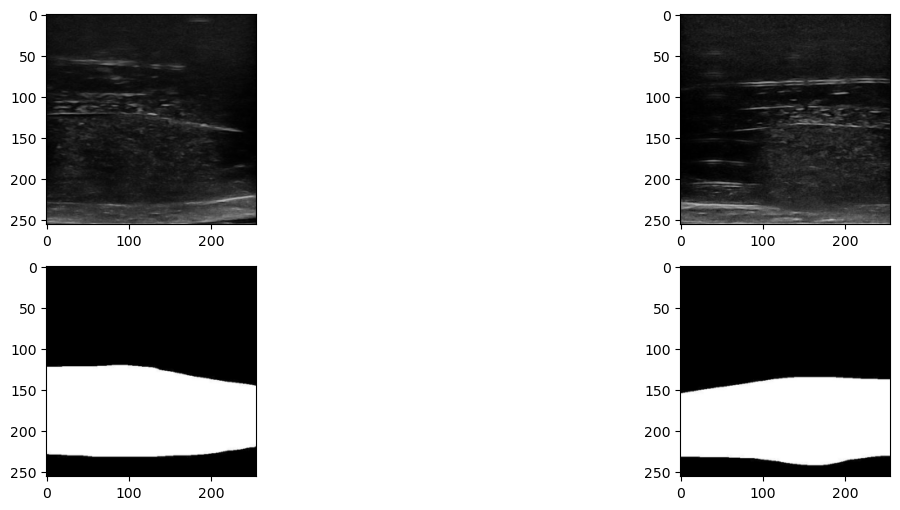

In [15]:
## Here we loop through our train_loader and see the images
fig = plt.figure(figsize = (15,6))

for ith_batch, sample_batched in enumerate(train_loader):
    print(ith_batch, sample_batched['image'].size(), sample_batched['mask'].size())

    for index in range(2):
        ax = fig.add_subplot(2, 2 , index + 1)  # subplot index starts from 1
        plt.imshow(im_converterX(sample_batched['image'][index]))
        ax = fig.add_subplot(2, 2, index + 3)
        plt.imshow(im_converterY(sample_batched['mask'][index]))
    break

In [16]:
class double_conv(nn.Module):
  '''(conv => BN => ReLU) * 2'''
  def __init__(self, in_ch, out_ch):
    super(double_conv, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      nn.ReLU(inplace=True),
      nn.Conv2d(out_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      nn.ReLU(inplace=True)
    )

  def forward(self, x):
    x = self.conv(x)
    return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x


class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=True):
    super(up, self).__init__()
    self.up = nn.Upsample(
      scale_factor=2, mode='bilinear', align_corners=True)
    self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x


class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

In [17]:
class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = False)
    self.up2 = up(512, 128, bilinear = False)
    self.up3 = up(256, 64, bilinear = False)
    self.up4 = up(128, 64, bilinear = False)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.5)

  def forward(self, x):
    x = x.float()
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)
    x5 = self.down4(x4)
    x = self.up1(x5, x4)
    x = self.up2(x, x3)
    x = self.dropout(x)
    x = self.up3(x, x2)
    x = self.up4(x, x1)
    x = self.outc(x)
    return torch.sigmoid(x)

In [18]:
model = UNet(1, 1)
model.to(device)
print(f"Model Loaded to {device}")

Model Loaded to mps


In [19]:
criterion = nn.BCELoss() # BCE = Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) # lr = learning rate

In [20]:
# calculates similarity index between predicted and actual segmentation
def dice_index(y_pred, y_actual):
  smooth = 0.000001 # prevent division by 0
  size_of_batch = y_pred.size(0)

  p1 = y_pred.view(size_of_batch, -1)
  p2 = y_actual.view(size_of_batch, -1)

  intersection = (p1 * p2).sum()

  dice =  ((2.0 * intersection )+ smooth) / (p1.sum() + p2.sum() + smooth)
  #dice.requires_grad = True

  return dice

# calculate dice loss which will be later used in loss function calculation
def dice_loss(y_predict, y_train): ## to add in bce looss
  return 1 -(dice_index(y_predict, y_train))

In [21]:
epochs = 40 # number of iterations of the training dataset during the training process

train_running_loss_history = []
validation_running_loss_history = []

model.to(device)

for e in range(epochs):
  train_running_loss = 0.0
  validation_running_loss = 0.0
  model.train()
  for ith_batch, sample_batched in enumerate(train_loader):
    X_train = sample_batched['image'].to(device)
    y_train = sample_batched['mask'].to(device)
    optimizer.zero_grad()
    y_pred = model(X_train) # hayo: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same
    loss = 0.30 * dice_loss(y_pred, y_train) +  0.70 * criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if ith_batch % 5 == 0:
      print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
    train_running_loss += loss.item()
  else:
    with torch.no_grad():
      model.eval()
      for ith_batch, sample_batched in enumerate(validation_loader):
        X_val = sample_batched['image'].to(device)
        y_val = sample_batched['mask'].to(device)
        y_out = model(X_val)
        out_val = (y_out + 0.5).int().float()
        val_loss = 0.3 * dice_loss(out_val, y_val)  + 0.7 * criterion(y_out, y_val)
        validation_running_loss += val_loss.item()
      print("================================================================================")
      print("Epoch {} completed".format(e + 1))

      train_epoch_loss = train_running_loss / len(train_loader)
      validation_epoch_loss = validation_running_loss / len(validation_loader)

      print("Average train loss is {}: ".format(train_epoch_loss))
      print("Average validation loss is {}".format(validation_epoch_loss))
      print("================================================================================")
      train_running_loss_history.append(train_epoch_loss)
      validation_running_loss_history.append(validation_epoch_loss)

  torch.mps.empty_cache() if device.type == 'mps' else torch.cuda.empty_cache()

/var/folders/4d/k9kg508s74x8f4h4b3sw0fsw0000gn/T/ipykernel_84777/3690571358.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  img_name = os.path.join(base_path, row[1])
/var/folders/4d/k9kg508s74x8f4h4b3sw0fsw0000gn/T/ipykernel_84777/3690571358.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask_name = os.path.join(base_path, row[1].replace('.jpeg', '_m.jpeg'))


Epoch:  1 Batch:  0 Current Loss:  0.6508549451828003


FileNotFoundError: [Errno 2] No such file or directory: '/Users/taliacho/Downloads/Bryan-Ranger/local_data/abs_neonatal_bw/capture_677_2024-08-10T17-28-46_c(1).jpeg'